In [34]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from tqdm import tqdm
from sklearn.datasets import load_files
from pyvi import ViTokenizer
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

In [35]:
base_dir = os.getcwd()
# tạo dir để lưu các hình ảnh
image_dir = os.path.join(base_dir, 'Ex8', 'data', 'images')
os.makedirs(image_dir, exist_ok = True)

In [36]:
news_dir = os.path.join(base_dir, 'Ex8', 'data', 'news_vnexpress')
os.listdir(news_dir)

['doi-song',
 'du-lich',
 'giai-tri',
 'giao-duc',
 'khoa-hoc',
 'kinh-doanh',
 'phap-luat',
 'suc-khoe',
 'the-thao',
 'thoi-su']

In [37]:
n = 0
for i in os.listdir(news_dir):
    print(f"{i}: {len(os.listdir(os.path.join(news_dir, i)))}")
    n+=len(os.listdir(os.path.join(news_dir, i)))
print(f"total article: {n}")

doi-song: 121
du-lich: 55
giai-tri: 202
giao-duc: 106
khoa-hoc: 145
kinh-doanh: 263
phap-luat: 59
suc-khoe: 163
the-thao: 174
thoi-su: 60
total article: 1348


In [38]:
# load data
data_train = load_files(container_path = news_dir, encoding = 'utf-8')

In [39]:
for ind, category in enumerate(data_train.target_names):
    print(f"{category} - {ind}")

doi-song - 0
du-lich - 1
giai-tri - 2
giao-duc - 3
khoa-hoc - 4
kinh-doanh - 5
phap-luat - 6
suc-khoe - 7
the-thao - 8
thoi-su - 9


In [40]:
len(data_train.data)

1348

In [41]:
stopword_dir = os.path.join(base_dir, 'Ex8', 'data', 'vietnamese-stopwords.txt')
with open(stopword_dir, 'r', encoding = 'utf-8') as f:
    stopwords = f.readlines()

stopwords

['a lô\n',
 'a ha\n',
 'ai\n',
 'ai ai\n',
 'ai nấy\n',
 'ai đó\n',
 'alô\n',
 'amen\n',
 'anh\n',
 'anh ấy\n',
 'ba\n',
 'ba ba\n',
 'ba bản\n',
 'ba cùng\n',
 'ba họ\n',
 'ba ngày\n',
 'ba ngôi\n',
 'ba tăng\n',
 'bao giờ\n',
 'bao lâu\n',
 'bao nhiêu\n',
 'bao nả\n',
 'bay biến\n',
 'biết\n',
 'biết bao\n',
 'biết bao nhiêu\n',
 'biết chắc\n',
 'biết chừng nào\n',
 'biết mình\n',
 'biết mấy\n',
 'biết thế\n',
 'biết trước\n',
 'biết việc\n',
 'biết đâu\n',
 'biết đâu chừng\n',
 'biết đâu đấy\n',
 'biết được\n',
 'buổi\n',
 'buổi làm\n',
 'buổi mới\n',
 'buổi ngày\n',
 'buổi sớm\n',
 'bà\n',
 'bà ấy\n',
 'bài\n',
 'bài bác\n',
 'bài bỏ\n',
 'bài cái\n',
 'bác\n',
 'bán\n',
 'bán cấp\n',
 'bán dạ\n',
 'bán thế\n',
 'bây bẩy\n',
 'bây chừ\n',
 'bây giờ\n',
 'bây nhiêu\n',
 'bèn\n',
 'béng\n',
 'bên\n',
 'bên bị\n',
 'bên có\n',
 'bên cạnh\n',
 'bông\n',
 'bước\n',
 'bước khỏi\n',
 'bước tới\n',
 'bước đi\n',
 'bạn\n',
 'bản\n',
 'bản bộ\n',
 'bản riêng\n',
 'bản thân\n',
 'bản ý\n',
 '

In [42]:
stopwords = [i.strip().replace(" ","_") for i in stopwords]
len(stopwords)

2063

In [43]:
module_count_vector = CountVectorizer(stop_words = stopwords)
model_tfidf = TfidfVectorizer(stop_words = stopwords)

In [44]:
data_preprocessed = model_tfidf.fit_transform(data_train.data, data_train.target)
data_preprocessed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 212056 stored elements and shape (1348, 12788)>

In [45]:
# chia dataset theo hold out train test không giao nhau
X_train, X_test, y_train, y_test = train_test_split(data_preprocessed, data_train.target, test_size = 0.2, random_state = 36)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1078, 12788), (270, 12788), (1078,), (270,))

In [46]:
def cross_validation(estimator):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X_train, y_train, cv = 10, n_jobs = -1, train_sizes = [1.0], scoring = 'accuracy')
    # đầu ra của train_scores và test_scores là ma trận 2d với số hàng là độ dài của train size số cột là số split trong cv
    # vì train size là 1 nên ma trận là ma trận 2d với đúng 1 hàng
    test_scores = test_scores[0]
    mean, std = test_scores.mean(), test_scores.std()
    return mean, std

In [47]:
def plot(title, xlabel, X, Y, error, ylabel = "Accuracy"):
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid()
    plt.ylabel(ylabel)
    plt.errorbar(X, Y, error, linestyle='None', marker='o')

100%|██████████| 2/2 [00:02<00:00,  1.13s/it]


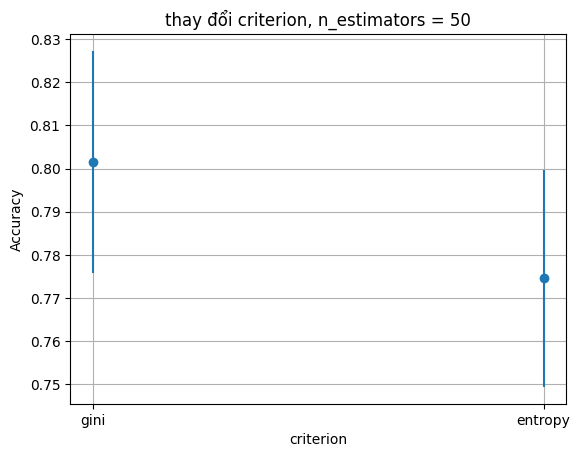

In [48]:
title = "thay đổi criterion, n_estimators = 50"
xlabel = "criterion"
X = []
Y = []
error = []
# lưu kết quả ra file ảnh
for criterion in tqdm(["gini", "entropy"]):
    text_clf = RandomForestClassifier(criterion=criterion, n_estimators=50)
    mean, std = cross_validation(text_clf)
    X.append(str(criterion))
    Y.append(mean)
    error.append(std)
plot(title, xlabel, X, Y, error)
plt.savefig(os.path.join(image_dir,'criterion.png'), bbox_inches='tight')
plt.show()

100%|██████████| 4/4 [00:08<00:00,  2.24s/it]


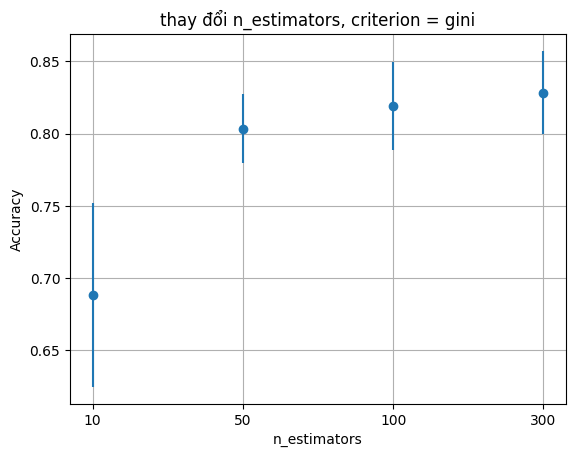

In [49]:
title = "thay đổi n_estimators, criterion = gini"
xlabel = "n_estimators"
X = []
Y = []
error = []
for n_estimators in tqdm([10, 50, 100, 300]):
# Với từng giá trị n_estimators nhận được,
# thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = RandomForestClassifier(criterion='gini', n_estimators=n_estimators)
    mean, std = cross_validation(text_clf)
    X.append(str(n_estimators))
    Y.append(mean)
    error.append(std)
# lưu kết quả ra file ảnh
plot(title, xlabel, X, Y, error)
plt.savefig(os.path.join(image_dir,'RF_change_N.png'), bbox_inches='tight')
plt.show()

100%|██████████| 4/4 [00:14<00:00,  3.65s/it]


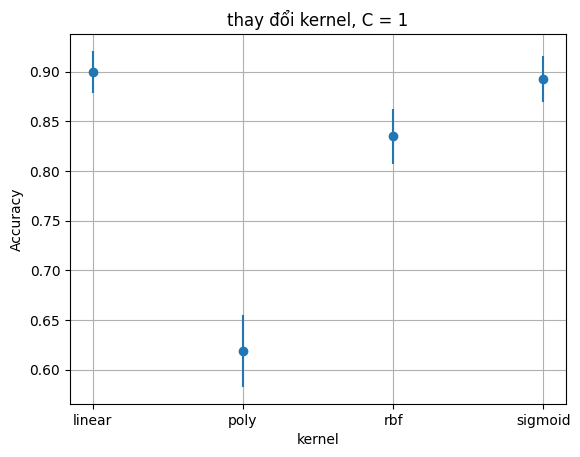

In [50]:
title = "thay đổi kernel, C = 1"
xlabel = "kernel"
X = []
Y = []
error = []
# lưu kết quả ra file ảnh
for kernel in tqdm(['linear', 'poly', 'rbf', 'sigmoid']):
# Với mỗi kernel được chọn,
# thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = svm.SVC(kernel=kernel, C=1.0)
    mean, std = cross_validation(text_clf)
    X.append(kernel)
    Y.append(mean)
    error.append(std)
plot(title, xlabel, X, Y, error)
plt.savefig(os.path.join(image_dir,'svm_change_kernel.png'), bbox_inches='tight')
plt.show()

100%|██████████| 5/5 [00:17<00:00,  3.53s/it]


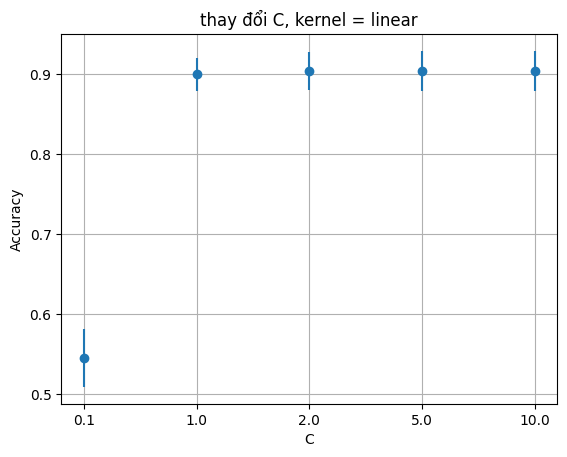

In [51]:
title = "thay đổi C, kernel = linear"
xlabel = "C"
X = []
Y = []
error = []
# lưu kết quả ra file ảnh
for C in tqdm([.1, 1.0, 2.0, 5.0, 10.0]):
# Với từng giá trị C nhận được,
# thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = svm.SVC(kernel='linear', C=C)
    mean, std = cross_validation(text_clf)
    X.append(str(C))
    Y.append(mean)
    error.append(std)
plot(title, xlabel, X, Y, error)
plt.savefig(os.path.join(image_dir,'svm_change_C.png'), bbox_inches='tight')
plt.show()

# So sánh các model

In [52]:
svm_model = svm.SVC(kernel='linear', C=1.0)
rf = RandomForestClassifier(criterion='gini', n_estimators=300)
knn = KNeighborsClassifier(n_neighbors=5)
# Huấn luyện các mô hình trên tập dữ liệu train đầy đủ
svm_model.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


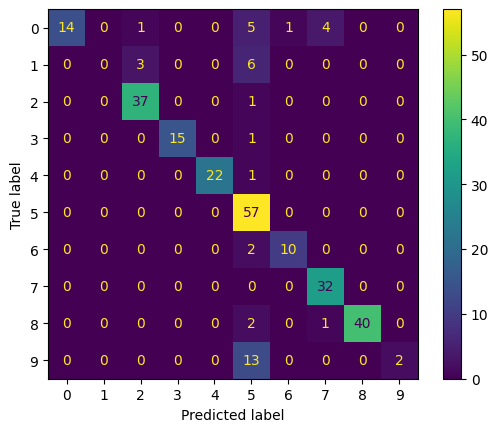

In [53]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

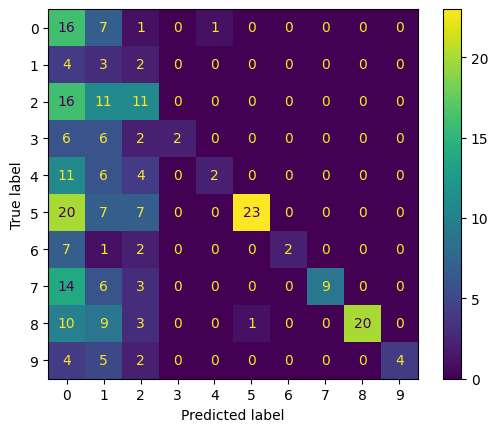

In [54]:
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)

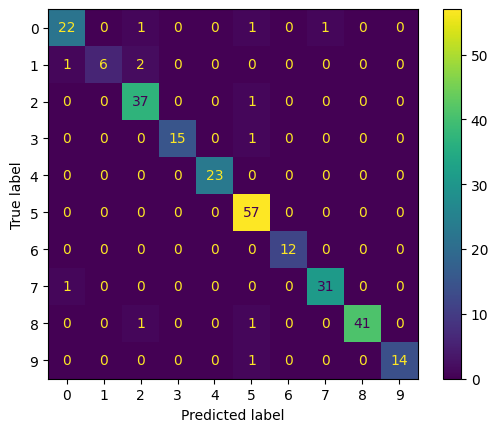

In [55]:
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test)

# German data


In [56]:
german_dir = os.path.join(base_dir, 'Ex8', 'data', 'german.data-numeric')
data = np.genfromtxt(german_dir)

In [57]:
X = data[:,:24]
y = data[:,-1]

In [58]:
X

array([[ 1.,  6.,  4., ...,  0.,  0.,  1.],
       [ 2., 48.,  2., ...,  0.,  0.,  1.],
       [ 4., 12.,  4., ...,  0.,  1.,  0.],
       ...,
       [ 4., 12.,  2., ...,  0.,  0.,  1.],
       [ 1., 45.,  2., ...,  0.,  0.,  1.],
       [ 2., 45.,  4., ...,  0.,  0.,  1.]], shape=(1000, 24))

In [77]:
def neg_cost(estimator, X, y):
    y_true = y
    y_pred = estimator.predict(X)
    true_pos = ((y_true==y_pred)&(y_true==1.0))*0.0
    true_ne = ((y_true==y_pred)&(y_true==2.0))*0.0
    false_ne = ((y_true!=y_pred)&(y_true==1.0))*1.0
    false_pos = ((y_true!=y_pred)&(y_true==2.0))*5.0
    return -sum(true_pos + true_ne + false_pos + false_ne)/len(y_true)

# muốn cost min thì neg cost max

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 36)

In [79]:
def find_best_param(estimator, params_grid):
    if estimator == 'rf':
        model = RandomForestClassifier(random_state = 36)
    if estimator == 'svm':
        model = svm.SVC(random_state = 36)
    # knn đã làm
    classifier = GridSearchCV(estimator = model,  param_grid = params_grid, cv = 5, n_jobs = -1, scoring = neg_cost)
    classifier.fit(X_train, y_train)
    print(classifier.best_estimator_)

In [80]:
param_rf = {
    'max_depth': [3, 11, 15, 24, 27],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features': [8],   # nên là n/3 cho phân loại
    'n_estimators': range(50,101,10)
}
find_best_param('rf', param_rf)

RandomForestClassifier(max_depth=11, max_features=8, n_estimators=80,
                       random_state=36)


In [81]:
param_svm = {'C': [0.01, 0.1, 1, 10, 100],
        'kernel':['linear','rbf', 'poly'] 
}
find_best_param('svm', param_svm)

SVC(C=100, kernel='linear', random_state=36)


In [85]:
best_rf = RandomForestClassifier(max_depth=11, max_features=8, n_estimators=80, random_state=36)
best_svm = svm.SVC(C=100, kernel='linear', random_state=36)

In [86]:
def plot_learning_curve(estimator, title):
    train_sizes, train_scores, test_scores = learning_curve(estimator = estimator, cv = 5, X = X_train, y = y_train, n_jobs = -1, train_sizes = np.linspace(0.1,1.0,5), scoring = neg_cost)
    train_means = np.mean(train_scores, axis = 1)
    train_std = np.std(train_scores, axis  = 1)
    test_means = np.mean(test_scores, axis = 1)
    test_std = np.mean(test_scores, axis = 1)
    plt.figure(figsize = (16,9))
    plt.title(title)
    plt.xlabel('train size')
    plt.ylabel('neg cost')
    plt.plot(train_sizes, train_means, color = 'r', label = 'train')
    plt.plot(train_sizes, test_means, color = 'b', label = 'test')
    plt.legend(loc = 'best')
    plt.show()
    

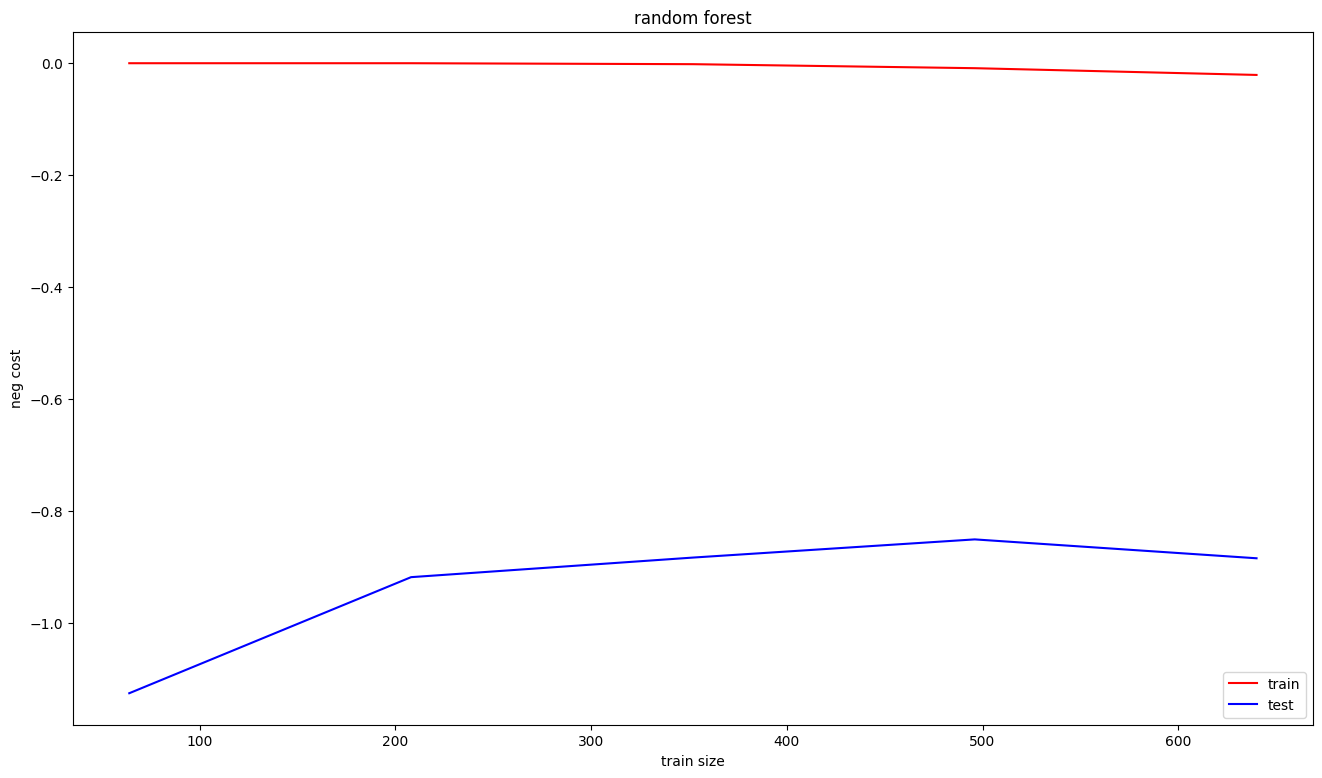

In [87]:
plot_learning_curve(best_rf, 'random forest')

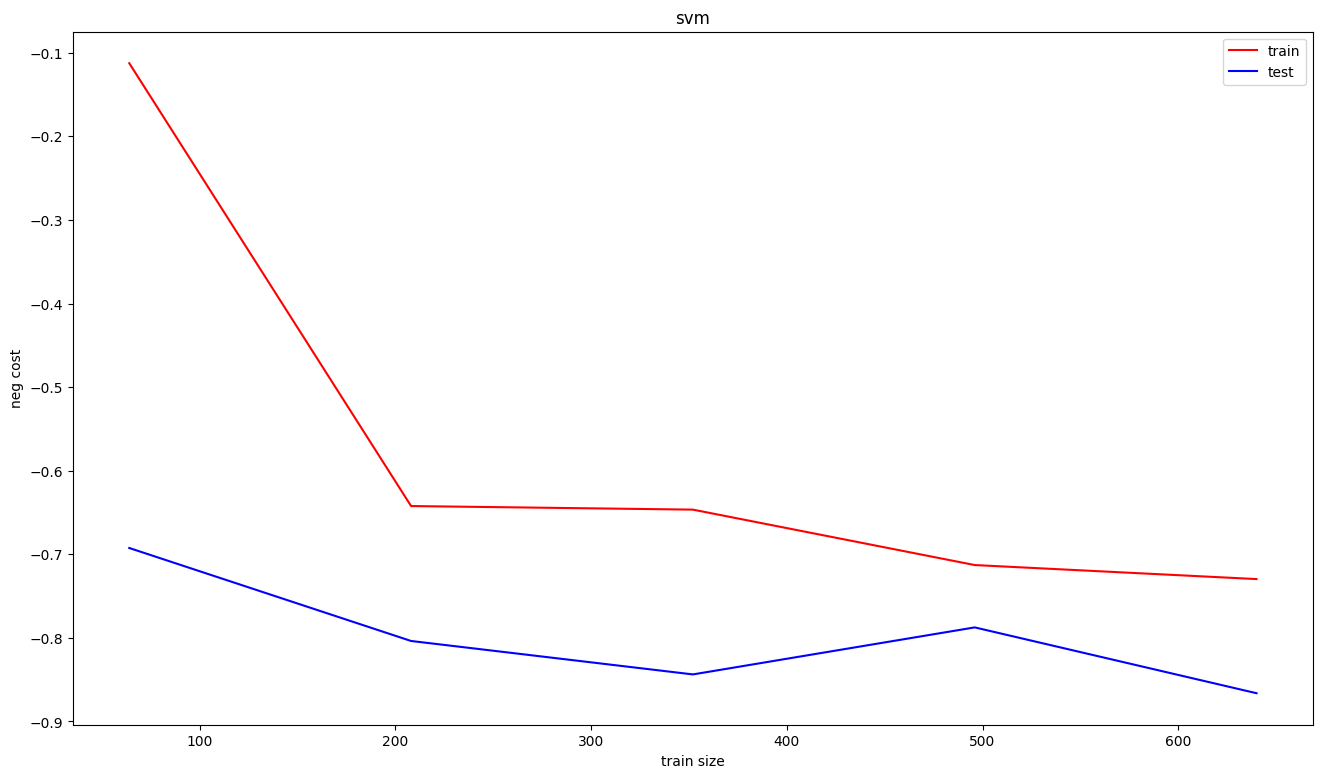

In [88]:
plot_learning_curve(best_svm, 'svm')